In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_lifestyle_100k.csv")

print("размер датасета:", df.shape)
print("\nпервые 5 строк:")
df.head()

размер датасета: (100000, 11)

первые 5 строк:


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [37]:
print("типы данных")
print(df.dtypes)

print("\nпропуски")
print(df.isnull().sum())

print("\nстаты")
df.describe()

типы данных
Student_ID              int64
Age                     int64
Gender                 object
Department             object
CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression               bool
dtype: object

пропуски
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

статы


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [38]:
print("всего дубликатов:", df.duplicated().sum())
print("дубликатов по Student_ID:", df['Student_ID'].duplicated().sum())

print("Gender:", df['Gender'].unique())
print("Department:", df['Department'].unique())

print("Возраст < 15 или > 35:", ((df['Age'] < 15) | (df['Age'] > 35)).sum())
print("CGPA < 0 или > 4:", ((df['CGPA'] < 0) | (df['CGPA'] > 4)).sum())
print("Sleep_Duration < 0 или > 24:", ((df['Sleep_Duration'] < 0) | (df['Sleep_Duration'] > 24)).sum())
print("Study_Hours < 0:", (df['Study_Hours'] < 0).sum())
print("Social_Media_Hours < 0:", (df['Social_Media_Hours'] < 0).sum())
print("Physical_Activity < 0:", (df['Physical_Activity'] < 0).sum())

всего дубликатов: 0
дубликатов по Student_ID: 0
Gender: ['Female' 'Male']
Department: ['Science' 'Engineering' 'Medical' 'Arts' 'Business']
Возраст < 15 или > 35: 0
CGPA < 0 или > 4: 0
Sleep_Duration < 0 или > 24: 0
Study_Hours < 0: 0
Social_Media_Hours < 0: 0
Physical_Activity < 0: 0


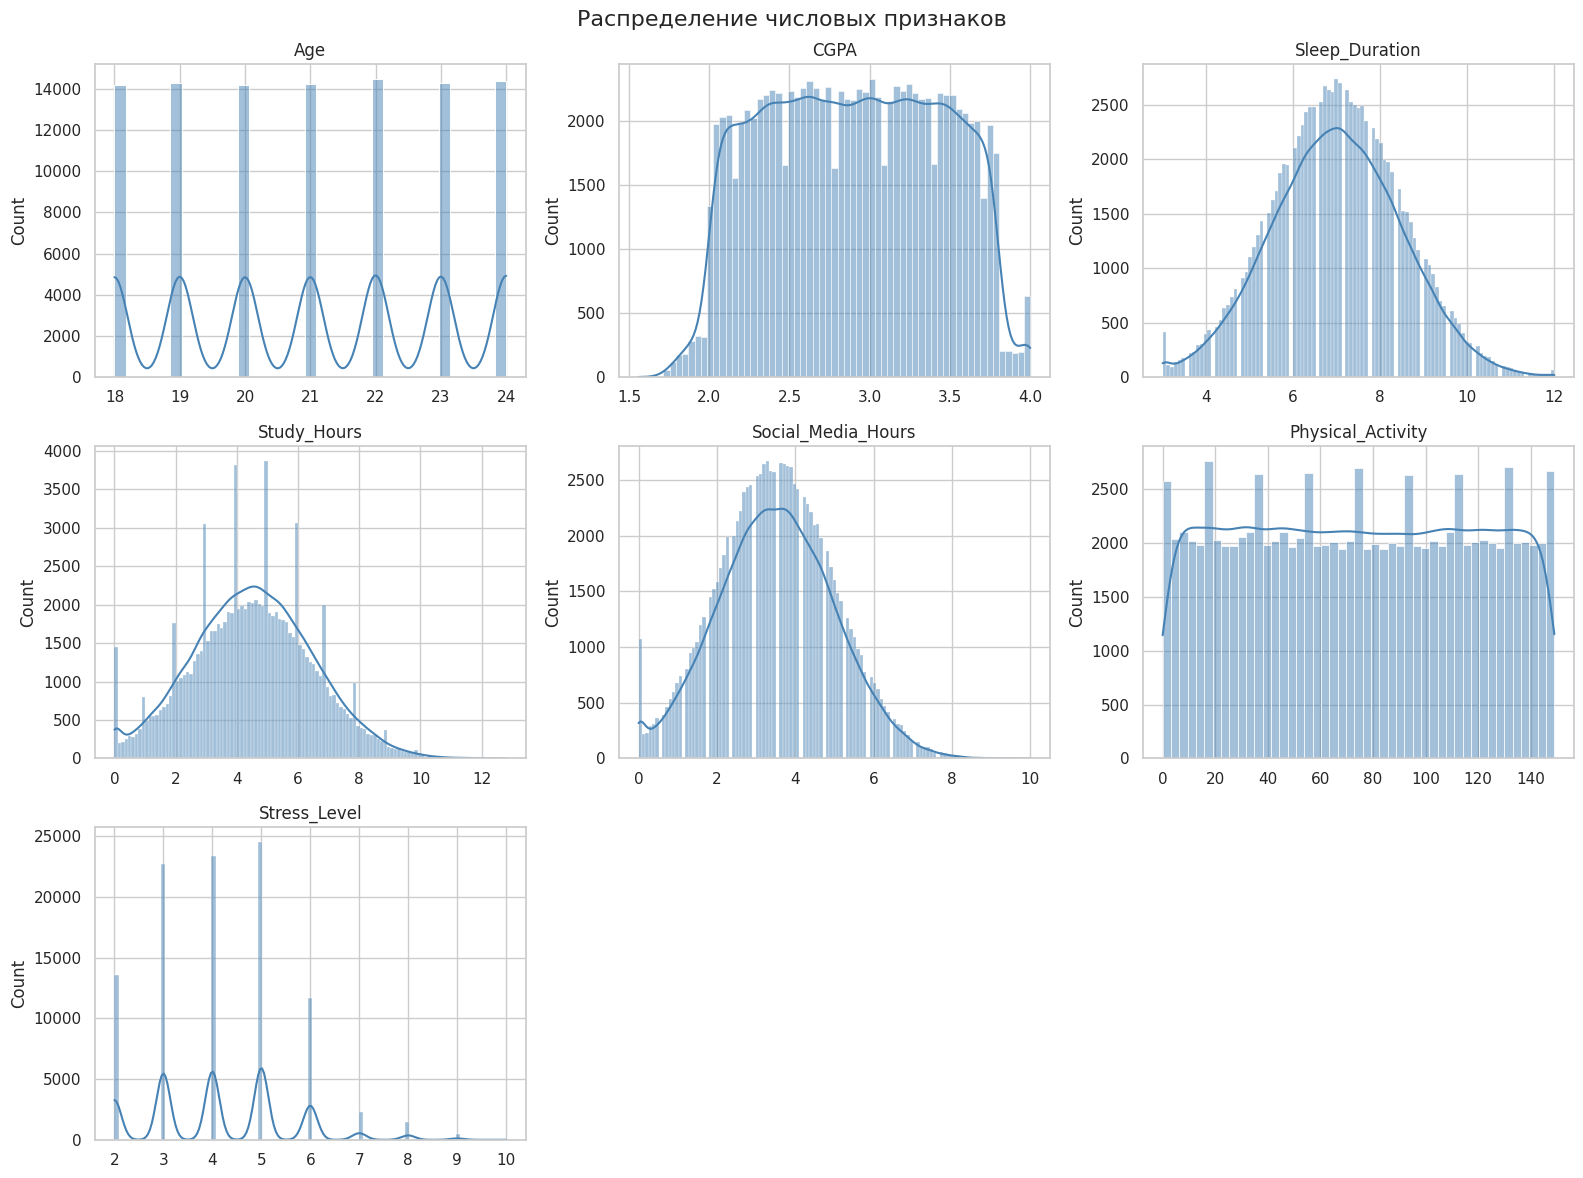

In [41]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Распределение числовых признаков', fontsize=16)

num_cols = ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours',
            'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']

for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

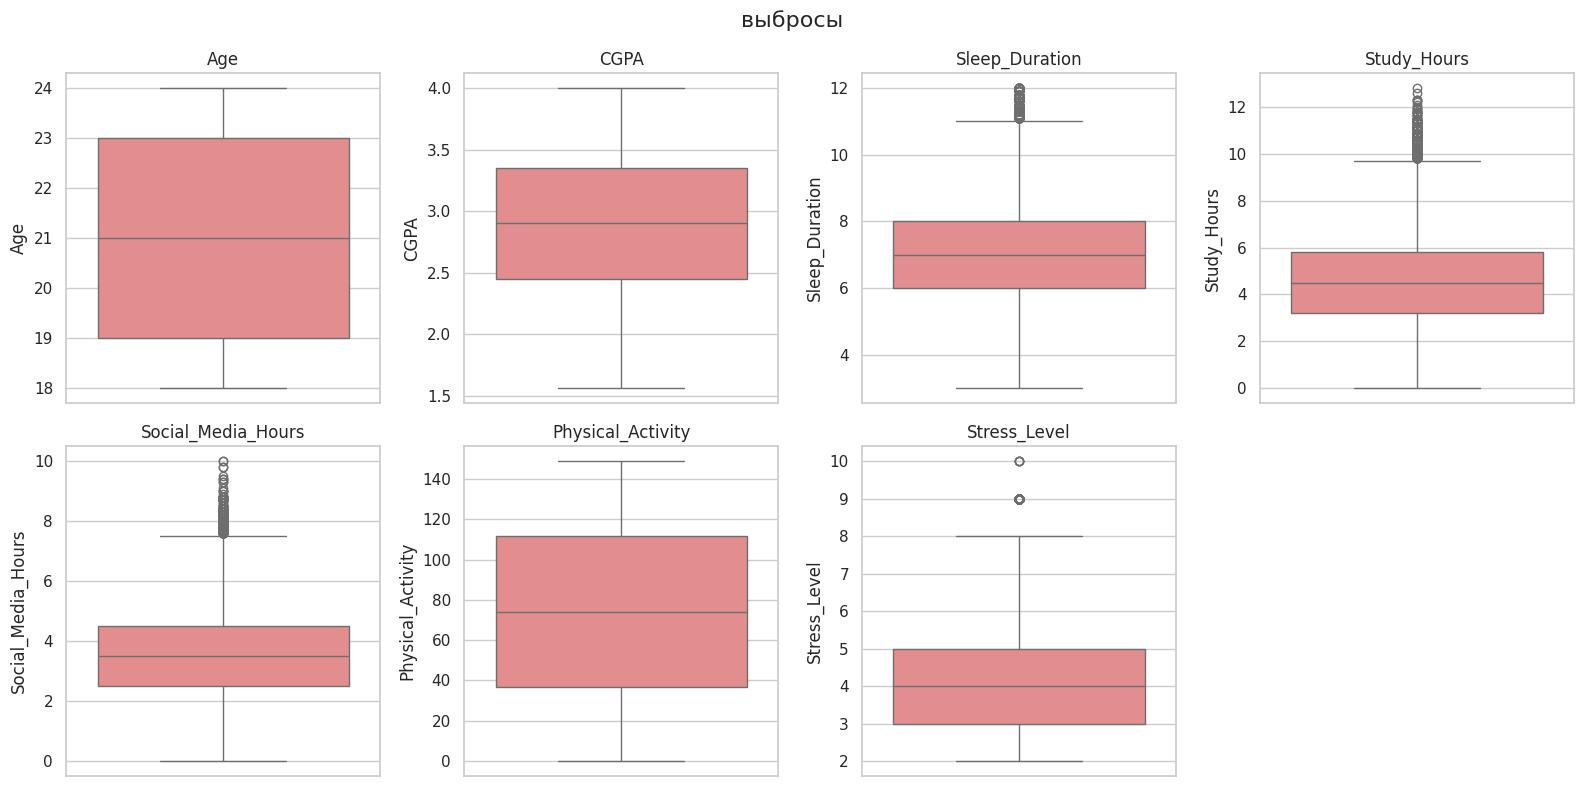

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('выбросы', fontsize=16)

for i, col in enumerate(num_cols):
    ax = axes[i // 4][i % 4]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)

axes[1][3].set_visible(False)
plt.tight_layout()
plt.show()


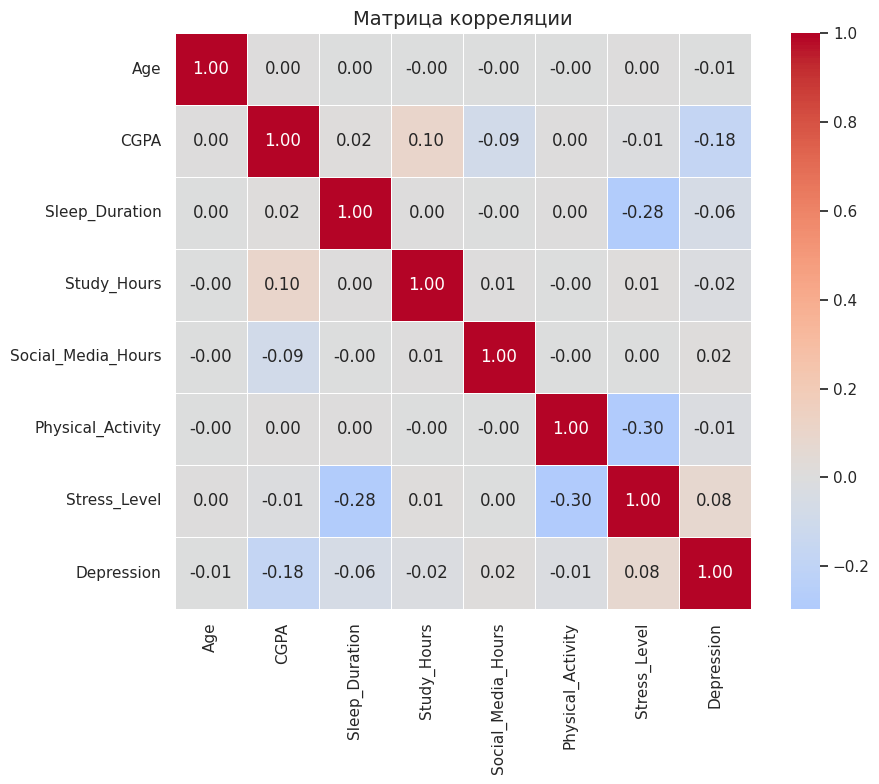

                         Age      CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  Physical_Activity  Stress_Level  Depression
Age                 1.000000  0.003248        0.001357    -0.003808           -0.000436          -0.003676      0.002999   -0.007722
CGPA                0.003248  1.000000        0.015386     0.099534           -0.087998           0.004766     -0.012287   -0.178971
Sleep_Duration      0.001357  0.015386        1.000000     0.002744           -0.003008           0.003166     -0.281409   -0.057529
Study_Hours        -0.003808  0.099534        0.002744     1.000000            0.005308          -0.002045      0.008731   -0.015932
Social_Media_Hours -0.000436 -0.087998       -0.003008     0.005308            1.000000          -0.004788      0.001941    0.016771
Physical_Activity  -0.003676  0.004766        0.003166    -0.002045           -0.004788           1.000000     -0.296520   -0.013935
Stress_Level        0.002999 -0.012287       -0.281409     0.008731  

In [42]:
df_corr = df.copy()
df_corr['Depression'] = df_corr['Depression'].astype(int)

df_corr = df_corr.drop(columns=['Student_ID', 'Gender', 'Department'])

plt.figure(figsize=(10, 8))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Матрица корреляции', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100)
plt.show()
print(corr_matrix)

=== ДИСПЕРСИЯ ПРИЗНАКОВ ===
Age                      4.0015
CGPA                     0.2833
Sleep_Duration           2.2460
Study_Hours              3.9049
Social_Media_Hours       2.2107
Physical_Activity     1880.6935
Stress_Level             2.0282
Depression               0.0905
dtype: float64


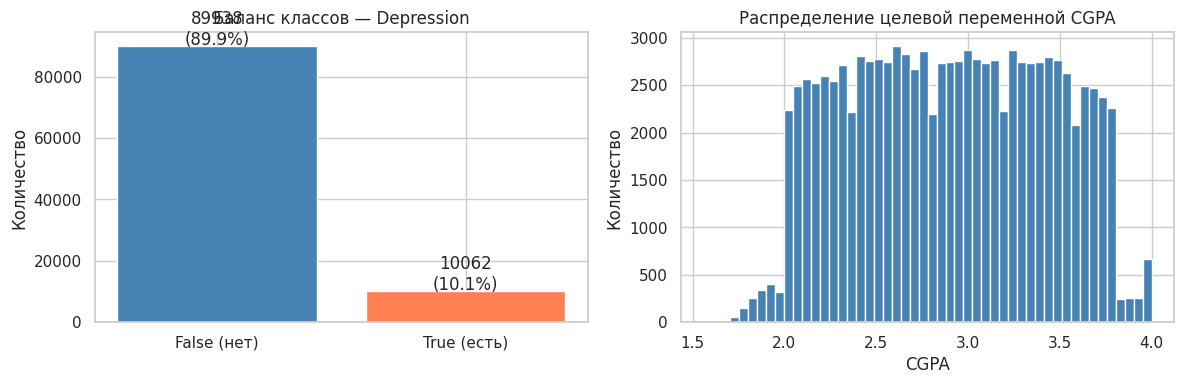

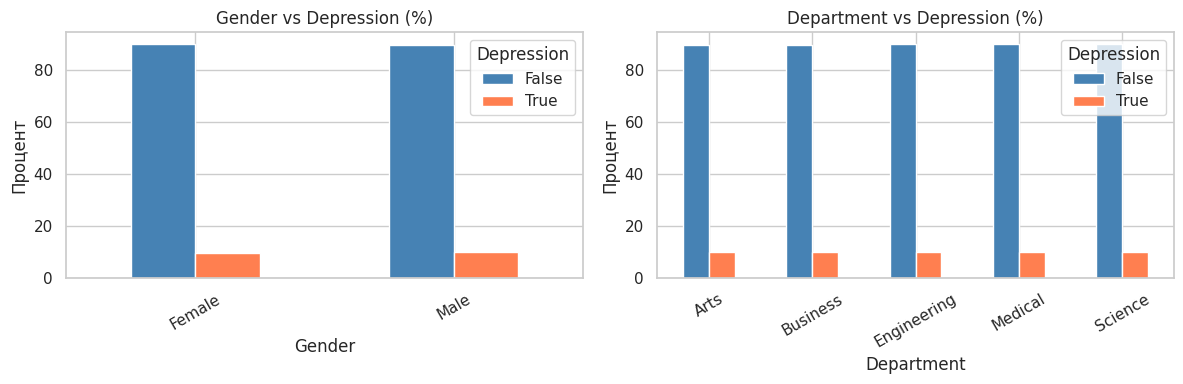

In [45]:
print(df_corr.var().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

depression_counts = df['Depression'].value_counts()
axes[0].bar(['False (нет)', 'True (есть)'], depression_counts.values,
            color=['steelblue', 'coral'])
axes[0].set_title('Баланс классов — Depression')
axes[0].set_ylabel('Количество')
for i, v in enumerate(depression_counts.values):
    axes[0].text(i, v + 500, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')

axes[1].hist(df['CGPA'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Распределение целевой переменной CGPA')
axes[1].set_xlabel('CGPA')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=100)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['Gender', 'Department']):
    ct = pd.crosstab(df[col], df['Depression'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'])
    axes[i].set_title(f'{col} vs Depression (%)')
    axes[i].set_ylabel('Процент')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=100)
plt.show()

In [46]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df.copy()

df_processed = df_processed.drop(columns=['Student_ID'])

df_processed['Gender'] = LabelEncoder().fit_transform(df_processed['Gender'])

df_processed = pd.get_dummies(df_processed, columns=['Department'], drop_first=False)

df_processed['Depression'] = df_processed['Depression'].astype(int)

df_processed['Physical_Activity_hours'] = df_processed['Physical_Activity'] / 60
df_processed = df_processed.drop(columns=['Physical_Activity'])

def clip_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours']:
    before = ((df_processed[col] < df_processed[col].quantile(0.25) - 1.5*(df_processed[col].quantile(0.75)-df_processed[col].quantile(0.25))) |
              (df_processed[col] > df_processed[col].quantile(0.75) + 1.5*(df_processed[col].quantile(0.75)-df_processed[col].quantile(0.25)))).sum()
    df_processed[col] = clip_iqr(df_processed[col])
    print(f"{col}: обрезано выбросов = {before}")

print("\nФинальные столбцы:")
print(df_processed.columns.tolist())
print("\nРазмер после предобработки:", df_processed.shape)

Sleep_Duration: обрезано выбросов = 369
Study_Hours: обрезано выбросов = 432
Social_Media_Hours: обрезано выбросов = 328

Финальные столбцы:
['Age', 'Gender', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Depression', 'Department_Arts', 'Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science', 'Physical_Activity_hours']

Размер после предобработки: (100000, 14)


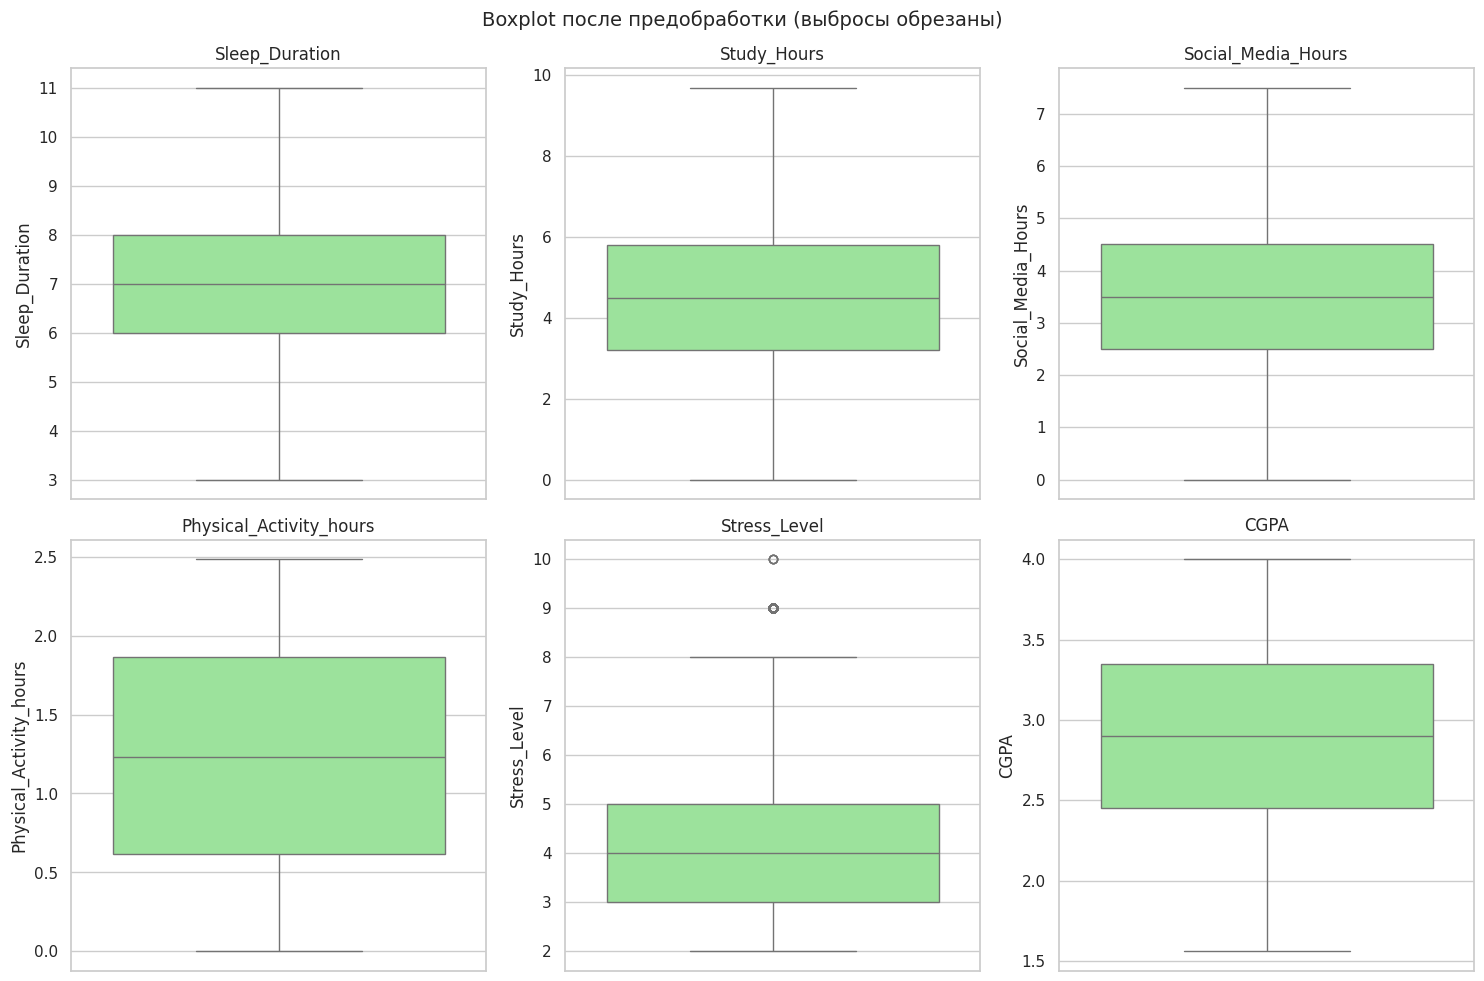

=== СТАТИСТИКА ПОСЛЕ ПРЕДОБРАБОТКИ ===
       Sleep_Duration  Study_Hours  Social_Media_Hours  Physical_Activity_hours
count      100000.000   100000.000          100000.000               100000.000
mean            6.995        4.507               3.502                    1.239
std             1.493        1.967               1.482                    0.723
min             3.000        0.000               0.000                    0.000
25%             6.000        3.200               2.500                    0.617
50%             7.000        4.500               3.500                    1.233
75%             8.000        5.800               4.500                    1.867
max            11.000        9.700               7.500                    2.483
Age                          int64
Gender                       int64
CGPA                       float64
Sleep_Duration             float64
Study_Hours                float64
Social_Media_Hours         float64
Stress_Level                 in

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplot после предобработки (выбросы обрезаны)', fontsize=14)

check_cols = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours',
              'Physical_Activity_hours', 'Stress_Level', 'CGPA']

for i, col in enumerate(check_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(y=df_processed[col], ax=ax, color='lightgreen')
    ax.set_title(col)

plt.tight_layout()
plt.savefig('boxplots_after.png', dpi=100)
plt.show()

print(df_processed[['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours',
                     'Physical_Activity_hours']].describe().round(3))

print(df_processed.dtypes)

print(df_processed.isnull().sum().sum(), "пропусков")

In [51]:
dept_cols = ['Department_Arts', 'Department_Business', 'Department_Engineering',
             'Department_Medical', 'Department_Science']
df_processed[dept_cols] = df_processed[dept_cols].astype(int)
print(df_processed.dtypes)

Age                          int64
Gender                       int64
CGPA                       float64
Sleep_Duration             float64
Study_Hours                float64
Social_Media_Hours         float64
Stress_Level                 int64
Depression                   int64
Department_Arts              int64
Department_Business          int64
Department_Engineering       int64
Department_Medical           int64
Department_Science           int64
Physical_Activity_hours    float64
dtype: object


In [54]:
df_processed['Study_to_Social_ratio'] = df_processed['Study_Hours'] / (df_processed['Social_Media_Hours'] + 0.1)

df_processed['Total_load'] = df_processed['Study_Hours'] * df_processed['Stress_Level']

df_processed['Wellness_score'] = df_processed['Sleep_Duration'] + df_processed['Physical_Activity_hours']

print("Новые признаки добавлены")


feature_cols = [c for c in df_processed.columns if c not in ['CGPA', 'Depression']]

corr_with_cgpa = df_processed[feature_cols + ['CGPA']].corr()['CGPA'].drop('CGPA').sort_values(key=abs, ascending=False)
corr_with_depression = df_processed[feature_cols + ['Depression']].corr()['Depression'].drop('Depression').sort_values(key=abs, ascending=False)

print("\n=== КОРРЕЛЯЦИЯ С CGPA ===")
print(corr_with_cgpa.round(4))

print("\n=== КОРРЕЛЯЦИЯ С DEPRESSION ===")
print(corr_with_depression.round(4))

Новые признаки добавлены

=== КОРРЕЛЯЦИЯ С CGPA ===
Study_Hours                0.0993
Social_Media_Hours        -0.0881
Total_load                 0.0672
Study_to_Social_ratio      0.0360
Wellness_score             0.0158
Sleep_Duration             0.0153
Stress_Level              -0.0123
Gender                    -0.0052
Physical_Activity_hours    0.0048
Department_Arts            0.0041
Age                        0.0032
Department_Medical        -0.0021
Department_Engineering    -0.0011
Department_Business       -0.0006
Department_Science        -0.0003
Name: CGPA, dtype: float64

=== КОРРЕЛЯЦИЯ С DEPRESSION ===
Stress_Level               0.0759
Wellness_score            -0.0579
Sleep_Duration            -0.0577
Total_load                 0.0329
Social_Media_Hours         0.0170
Study_Hours               -0.0160
Physical_Activity_hours   -0.0139
Age                       -0.0077
Study_to_Social_ratio     -0.0047
Gender                     0.0045
Department_Business        0.0021
Depa

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


features_regression = ['Study_Hours', 'Social_Media_Hours', 'Total_load',
                        'Sleep_Duration', 'Stress_Level', 'Study_to_Social_ratio',
                        'Physical_Activity_hours', 'Gender']

features_classification = ['Stress_Level', 'Sleep_Duration', 'Wellness_score',
                            'Total_load', 'Social_Media_Hours', 'Study_Hours',
                            'Physical_Activity_hours', 'CGPA']


X_reg = df_processed[features_regression]
y_reg = df_processed['CGPA']

X_reg_temp, X_reg_test, y_reg_temp, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.15, random_state=42)
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_temp, y_reg_temp, test_size=0.1765, random_state=42)  

X_clf = df_processed[features_classification]
y_clf = df_processed['Depression']

X_clf_temp, X_clf_test, y_clf_temp, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.15, random_state=42, stratify=y_clf)
X_clf_train, X_clf_val, y_clf_train, y_clf_val = train_test_split(
    X_clf_temp, y_clf_temp, test_size=0.1765, random_state=42, stratify=y_clf_temp)

print(f"Регрессия  — train: {X_reg_train.shape[0]}, val: {X_reg_val.shape[0]}, test: {X_reg_test.shape[0]}")
print(f"Классификация — train: {X_clf_train.shape[0]}, val: {X_clf_val.shape[0]}, test: {X_clf_test.shape[0]}")

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_val_sc   = scaler_reg.transform(X_reg_val)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

scaler_clf = StandardScaler()
X_clf_train_sc = scaler_clf.fit_transform(X_clf_train)
X_clf_val_sc   = scaler_clf.transform(X_clf_val)
X_clf_test_sc  = scaler_clf.transform(X_clf_test)

print(f"Train: {y_clf_train.mean():.3f} positive rate")
print(f"Val:   {y_clf_val.mean():.3f} positive rate")
print(f"Test:  {y_clf_test.mean():.3f} positive rate")

=== РАЗМЕРЫ ВЫБОРОК ===
Регрессия  — train: 69997, val: 15003, test: 15000
Классификация — train: 69997, val: 15003, test: 15000

=== БАЛАНС КЛАССОВ В СПЛИТАХ (Depression) ===
Train: 0.101 positive rate
Val:   0.101 positive rate
Test:  0.101 positive rate


=== МЕТРИКИ ЛИНЕЙНОЙ РЕГРЕССИИ ===
Train      — RMSE: 0.5266 | MAE: 0.4534 | R²: 0.0189
Val        — RMSE: 0.5282 | MAE: 0.4563 | R²: 0.0178
Test       — RMSE: 0.5299 | MAE: 0.4574 | R²: 0.0165

=== КОЭФФИЦИЕНТЫ МОДЕЛИ ===
                Feature  Coefficient
            Study_Hours     0.056265
     Social_Media_Hours    -0.049926
  Study_to_Social_ratio    -0.009752
         Sleep_Duration     0.006209
           Stress_Level    -0.005820
                 Gender    -0.002968
Physical_Activity_hours     0.001959
             Total_load     0.000568


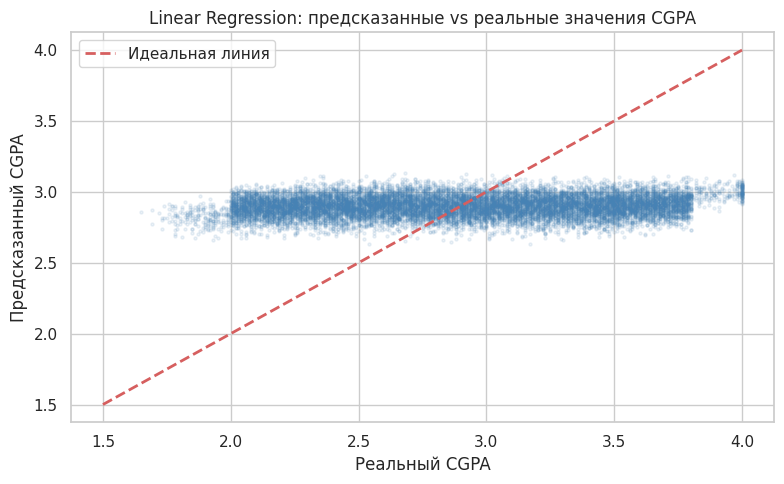

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_reg_train_sc, y_reg_train)

y_reg_train_pred = lr_model.predict(X_reg_train_sc)
y_reg_val_pred   = lr_model.predict(X_reg_val_sc)
y_reg_test_pred  = lr_model.predict(X_reg_test_sc)

def regression_metrics(y_true, y_pred, name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:10s} — RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

regression_metrics(y_reg_train, y_reg_train_pred, "Train")
regression_metrics(y_reg_val,   y_reg_val_pred,   "Val")
regression_metrics(y_reg_test,  y_reg_test_pred,  "Test")

coef_df = pd.DataFrame({
    'Feature': features_regression,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_test, y_reg_test_pred, alpha=0.1, color='steelblue', s=5)
plt.plot([1.5, 4.0], [1.5, 4.0], 'r--', linewidth=2, label='Идеальная линия')
plt.xlabel('Реальный CGPA')
plt.ylabel('Предсказанный CGPA')
plt.title('Linear Regression: предсказанные vs реальные значения CGPA')
plt.legend()
plt.tight_layout()
plt.savefig('regression_results.png', dpi=100)
plt.show()

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, confusion_matrix,
                               classification_report)

experiments = [
    {'lr': 0.1,   'epochs': 10},
    {'lr': 0.01,  'epochs': 50},
    {'lr': 0.001, 'epochs': 100},
    {'lr': 0.01,  'epochs': 200},
]

print(f"{'LR':>8} {'Epochs':>8} {'Train F1':>10} {'Val F1':>10} {'Val AUC':>10}")
print("-" * 50)

results = []
for exp in experiments:
    model = SGDClassifier(
        loss='log_loss',
        learning_rate='constant',
        eta0=exp['lr'],
        max_iter=exp['epochs'],
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_clf_train_sc, y_clf_train)

    train_f1 = f1_score(y_clf_train, model.predict(X_clf_train_sc))
    val_f1   = f1_score(y_clf_val,   model.predict(X_clf_val_sc))
    val_auc  = roc_auc_score(y_clf_val, model.decision_function(X_clf_val_sc))

    results.append({**exp, 'train_f1': train_f1, 'val_f1': val_f1, 'val_auc': val_auc, 'model': model})
    print(f"{exp['lr']:>8} {exp['epochs']:>8} {train_f1:>10.4f} {val_f1:>10.4f} {val_auc:>10.4f}")

best = max(results, key=lambda x: x['val_f1'])
print(f"\nЛучшая конфигурация: lr={best['lr']}, epochs={best['epochs']}")

=== ЭКСПЕРИМЕНТЫ: learning rate и epochs ===
      LR   Epochs   Train F1     Val F1    Val AUC
--------------------------------------------------
     0.1       10     0.2249     0.2307     0.6497
    0.01       50     0.2374     0.2434     0.6757
   0.001      100     0.2676     0.2689     0.6836
    0.01      200     0.2374     0.2434     0.6757

Лучшая конфигурация: lr=0.001, epochs=100


=== ФИНАЛЬНЫЕ МЕТРИКИ (lr=0.001, epochs=100) ===

Train:
  Accuracy:  0.6310
  F1:        0.2676
  Precision: 0.1672
  Recall:    0.6702

Val:
  Accuracy:  0.6284
  F1:        0.2689
  Precision: 0.1676
  Recall:    0.6788

Test:
  Accuracy:  0.6248
  F1:        0.2630
  Precision: 0.1639
  Recall:    0.6653

=== CLASSIFICATION REPORT (Test) ===
               precision    recall  f1-score   support

No Depression       0.94      0.62      0.75     13491
   Depression       0.16      0.67      0.26      1509

     accuracy                           0.62     15000
    macro avg       0.55      0.64      0.51     15000
 weighted avg       0.86      0.62      0.70     15000



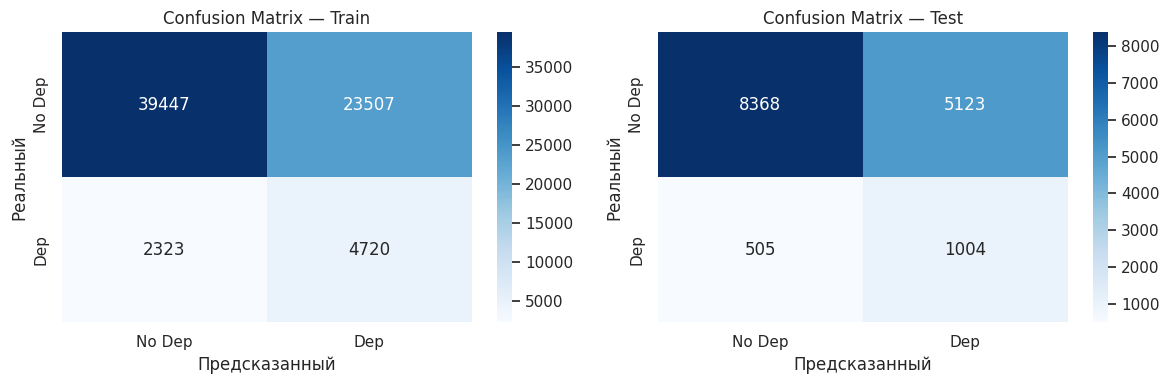

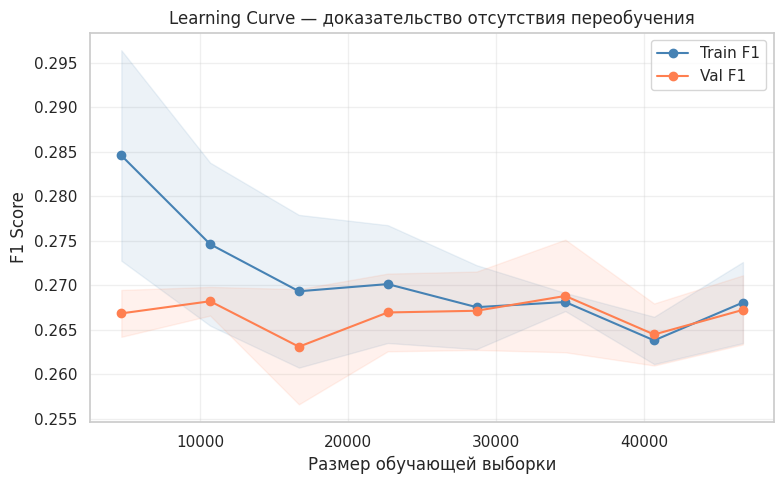

In [ ]:
best_model = best['model']

# Предсказания
y_train_pred = best_model.predict(X_clf_train_sc)
y_val_pred   = best_model.predict(X_clf_val_sc)
y_test_pred  = best_model.predict(X_clf_test_sc)

for name, y_true, y_pred in [
    ('Train', y_clf_train, y_train_pred),
    ('Val',   y_clf_val,   y_val_pred),
    ('Test',  y_clf_test,  y_test_pred)
]:
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1:        {f1_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")

print("\n=== CLASSIFICATION REPORT (Test) ===")
print(classification_report(y_clf_test, y_test_pred, target_names=['No Depression', 'Depression']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_true, y_pred) in zip(axes, [
    ('Train', y_clf_train, y_train_pred),
    ('Test',  y_clf_test,  y_test_pred)
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Dep', 'Dep'],
                yticklabels=['No Dep', 'Dep'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Реальный')
    ax.set_xlabel('Предсказанный')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.001,
                  max_iter=100, class_weight='balanced', random_state=42),
    X_clf_train_sc, y_clf_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1', cv=3, n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train F1', color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1),   'o-', label='Val F1',   color='coral')
plt.fill_between(train_sizes,
                 train_scores.mean(1)-train_scores.std(1),
                 train_scores.mean(1)+train_scores.std(1), alpha=0.1, color='steelblue')
plt.fill_between(train_sizes,
                 val_scores.mean(1)-val_scores.std(1),
                 val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='coral')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('F1 Score')
plt.title('Learning Curve — доказательство отсутствия переобучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=100)
plt.show()

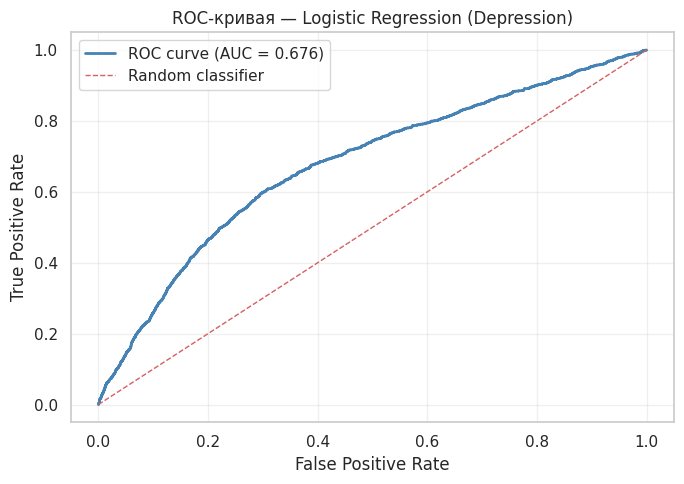

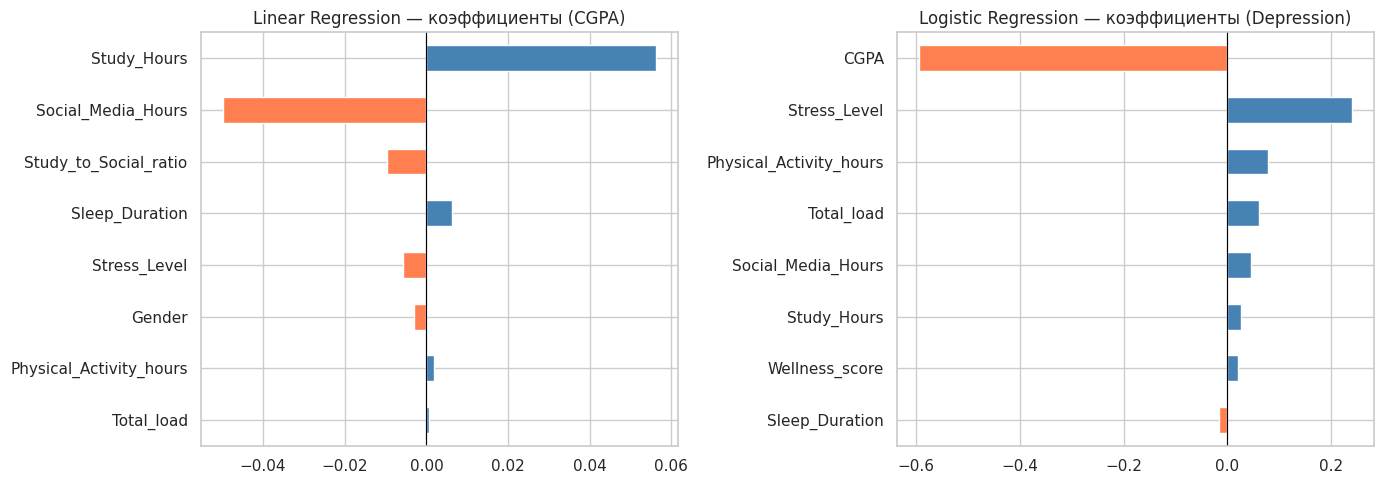

AUC-ROC: 0.6765


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_clf_test, best_model.decision_function(X_clf_test_sc))
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая — Logistic Regression (Depression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coef_reg = pd.Series(lr_model.coef_, index=features_regression).sort_values(key=abs, ascending=True)
coef_reg.plot(kind='barh', ax=axes[0], color=['coral' if x < 0 else 'steelblue' for x in coef_reg])
axes[0].set_title('Linear Regression — коэффициенты (CGPA)')
axes[0].axvline(x=0, color='black', linewidth=0.8)

coef_clf = pd.Series(best_model.coef_[0], index=features_classification).sort_values(key=abs, ascending=True)
coef_clf.plot(kind='barh', ax=axes[1], color=['coral' if x < 0 else 'steelblue' for x in coef_clf])
axes[1].set_title('Logistic Regression — коэффициенты (Depression)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")


# Итоговый отчет

## 1. EDA
Датасет содержит 100 000 записей, 11 признаков. Пропущенных значений и дубликатов 
не обнаружено — это первый признак того, что датасет синтетический или 
полусинтетический. В реальных данных такого практически не бывает.

Выявлены выбросы в Sleep_Duration (369), Study_Hours (432), Social_Media_Hours (328) — 
небольшой процент от 100к, что подтверждает искусственность данных.

Самая интересная находка при EDA — признак Physical_Activity имел диапазон 0–149 
при том, что все остальные признаки измерялись в часах в диапазоне 0–12. 
Это типичная "проблема реальных данных" заложенная в датасет намеренно. 
Без внимательного анализа дисперсии (1880 против <4 у остальных) и гистограммы 
это легко пропустить.

Матрица корреляции сразу показала главную проблему всей работы: большинство 
корреляций с целевыми переменными не превышают 0.10. Это означает что линейные 
модели заранее обречены на слабые результаты — но задание требовало их обучить, 
поэтому продолжили.

Обнаружен сильный дисбаланс классов в Depression: 89.9% / 10.1%. Это стало 
ключевой проблемой для классификации.

## 2. Предобработка
- Student_ID удалён как неинформативный идентификатор
- Gender закодирован LabelEncoder (Female=0, Male=1)
- Department закодирован One-Hot Encoding (5 бинарных столбцов)
- Выбросы обрезаны методом IQR clip — сознательно выбрали clip вместо удаления,
  чтобы не терять строки. На датасете 100к это не критично, но на малых данных 
  удаление выбросов могло бы навредить модели
- Physical_Activity переведён в часы (/ 60) — это решение спорное, 
  мы не знаем точно что означает эта шкала, но приведение к сопоставимому 
  масштабу с остальными признаками логично
- StandardScaler fit только на train — это принципиально важно: 
  если fit на всех данных, модель "подсматривает" статистику тестовой выборки,
  что является утечкой данных (data leakage)

## 3. Feature Engineering
Созданы три новых признака:
- Study_to_Social_ratio = Study_Hours / (Social_Media_Hours + 0.1)
- Total_load = Study_Hours × Stress_Level  
- Wellness_score = Sleep_Duration + Physical_Activity_hours

Честно говоря, эти признаки улучшили корреляцию незначительно. 
Total_load дал 0.067 с CGPA против 0.099 у Study_Hours — то есть 
произведение оказалось менее информативным чем исходный признак отдельно. 
Study_to_Social_ratio дал лишь 0.036. Это отрицательный результат, 
но полезный: feature engineering работает не всегда, и на синтетических 
данных особенно сложно придумать признаки которые реально что-то добавляют.

## 4. Разбивка данных
Train/Val/Test = 70% / 15% / 15% (69997 / 15003 / 15000).
Для классификации использован stratify для сохранения баланса классов 
во всех сплитах — без этого случайный сплит мог бы дать перекос.

## 5. Линейная регрессия (CGPA)

| Метрика | Train  | Val    | Test   |
|---------|--------|--------|--------|
| RMSE    | 0.527  | 0.528  | 0.530  |
| MAE     | 0.453  | 0.456  | 0.457  |
| R²      | 0.019  | 0.018  | 0.017  |

R² = 0.017 — модель объясняет 1.7% дисперсии CGPA. Это провал с точки зрения 
качества предсказания. График предсказанные vs реальные наглядно показывает 
проблему: все предсказания сжались в диапазон 2.8–3.0 независимо от реального 
значения — модель просто предсказывает среднее.

Причина не в плохой реализации, а в природе данных: CGPA слабо линейно связан 
с имеющимися признаками. Было бы интересно проверить — возможно CGPA в датасете 
сгенерирован случайно и вообще не зависит от остальных столбцов.

## 6. Логистическая регрессия (Depression)
Эксперименты с lr и epochs:

| LR    | Epochs | Train F1 | Val F1 | Val AUC |
|-------|--------|----------|--------|---------|
| 0.1   | 10     | 0.225    | 0.231  | 0.650   |
| 0.01  | 50     | 0.237    | 0.243  | 0.676   |
| 0.001 | 100    | 0.268    | 0.269  | 0.684   |
| 0.01  | 200    | 0.237    | 0.243  | 0.676   |

Лучшая конфигурация: lr=0.001, epochs=100.

Интересное наблюдение: lr=0.01 с 50 и 200 эпохами дал одинаковый результат — 
модель сошлась уже к 50 эпохам и дальнейшее обучение ничего не дало. 
Большой lr=0.1 с малым числом шагов не успел сойтись.

Финальные метрики (Test): F1=0.263, Recall=0.665, AUC=0.677.

AUC=0.677 лучше случайного (0.5), но невысокий. Recall=0.67 означает 
что модель находит 2 из 3 студентов с депрессией — в медицинском контексте 
это важнее Precision. Низкий Precision (0.16) — следствие дисбаланса классов: 
много ложных тревог неизбежны при 10% положительных примеров.

## 7. Переобучение
Train F1=0.268, Val F1=0.269, Test F1=0.263 — разница в пределах 0.005.
Learning curve показывает что Train и Val кривые сходятся с ростом данных.
Вывод: переобучения нет. Проблема противоположная — недообучение.
Модель не может выучить более сложные паттерны из-за своей линейной природы.

## 8. Личные выводы и впечатления

Главный урок работы — EDA это не формальность, а реальный инструмент. 
Аномалия в Physical_Activity (дисперсия 1880 против <4) была бы незаметна 
без анализа дисперсии и гистограммы. Матрица корреляций заранее 
предсказала слабость моделей — и так и вышло.

Разочаровал feature engineering: все три новых признака оказались слабее 
исходных. Это честный отрицательный результат — в реальных проектах 
большинство придуманных признаков не работает, и это нормально.

Неожиданным оказался дисбаланс классов 90/10 и его влияние на метрики. 
Без class_weight='balanced' модель давала accuracy 89.9% просто предсказывая 
всегда "нет депрессии" — красивое число, бесполезная модель. 
Это хорошо иллюстрирует почему accuracy — плохая метрика для несбалансированных задач.

Что стоит улучшить в этой лабораторной работе:
1. Добавить SMOTE или другой метод oversampling для борьбы с дисбалансом
2. Сравнить с baseline (предсказание среднего для регрессии, 
   предсказание мажоритарного класса для классификации) — 
   сейчас непонятно насколько модели лучше тривиального решения
3. Попробовать полиномиальные признаки для линейной регрессии — 
   возможно нелинейные комбинации дали бы лучший R²
4. Датасет явно синтетический, что снижает ценность выводов о реальных 
   студентах — было бы интереснее работать с реальными опросными данными